Device: cuda
PyTorch: 2.5.1+cu121, Torchvision: 0.20.1+cu121
Files already downloaded and verified


d:\pythonprojects\practice-github\torch_final\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Train: 50000 samples, Test: 10000 samples

>>> 实验 A：冻结骨干（Frozen Backbone）


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\yuhao.bian/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


  Total params:       11,181,642
  Trainable params:        5,130
  Ratio:            0.0459%

  Training: Frozen Backbone (FC only)
  Epoch  1/15 | Train Loss: 1.6251 Acc: 0.4428 | Test Loss: 1.3989 Acc: 0.5373 | LR: 0.000989 ★
  Epoch  2/15 | Train Loss: 1.3382 Acc: 0.5434 | Test Loss: 1.3217 Acc: 0.5629 | LR: 0.000957 ★
  Epoch  3/15 | Train Loss: 1.2829 Acc: 0.5600 | Test Loss: 1.2942 Acc: 0.5707 | LR: 0.000905 ★
  Epoch  4/15 | Train Loss: 1.2633 Acc: 0.5664 | Test Loss: 1.2808 Acc: 0.5712 | LR: 0.000835 ★
  Epoch  5/15 | Train Loss: 1.2467 Acc: 0.5744 | Test Loss: 1.2712 Acc: 0.5756 | LR: 0.000750 ★
  Epoch  6/15 | Train Loss: 1.2360 Acc: 0.5781 | Test Loss: 1.2632 Acc: 0.5762 | LR: 0.000655 ★
  Epoch  7/15 | Train Loss: 1.2308 Acc: 0.5789 | Test Loss: 1.2566 Acc: 0.5788 | LR: 0.000552 ★
  Epoch  8/15 | Train Loss: 1.2264 Acc: 0.5800 | Test Loss: 1.2594 Acc: 0.5775 | LR: 0.000448
  Epoch  9/15 | Train Loss: 1.2269 Acc: 0.5797 | Test Loss: 1.2580 Acc: 0.5792 | LR: 0.000345 ★
  Epo

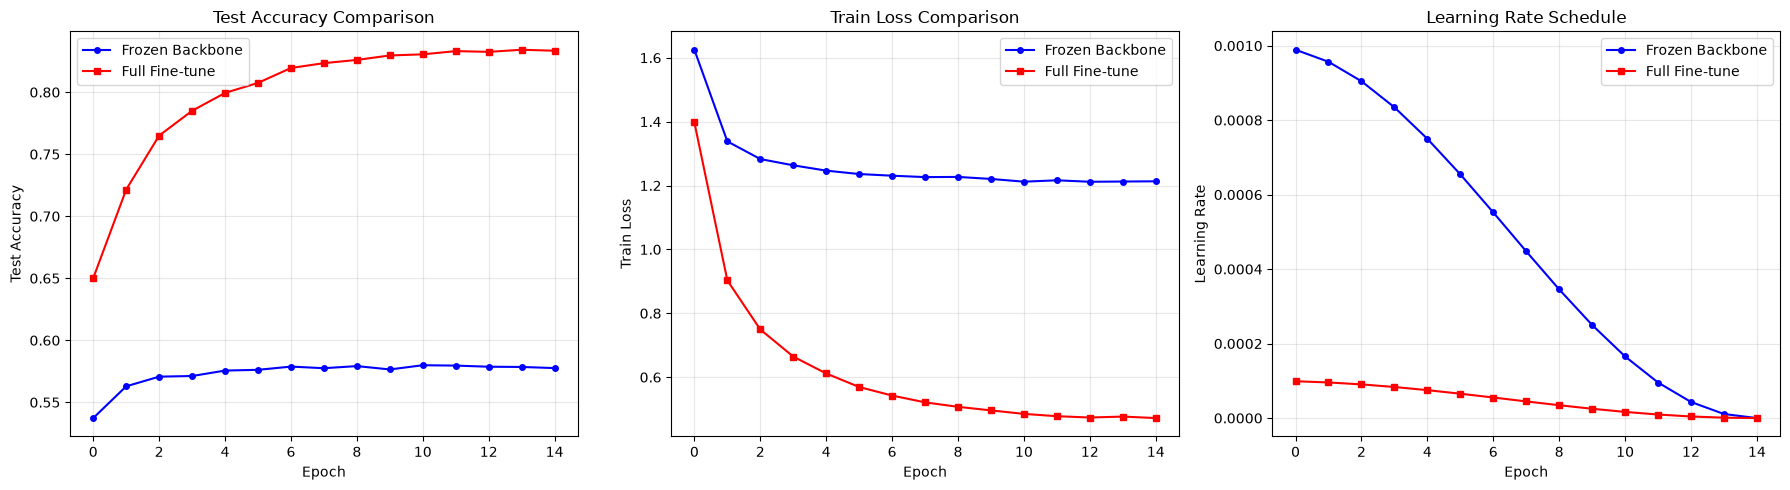


指标                              冻结骨干            全量微调
------------------------------------------------------------
Best Test Acc                57.99%         83.42%
Final Train Acc              58.42%         83.77%
Training Time                333.7s         387.8s
Trainable Params               5,130      11,181,642


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import copy
import time
import matplotlib.pyplot as plt

# ============================================================
# 0. 全局配置
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_CLASSES = 10
NUM_EPOCHS = 15          # 冻结骨干通常收敛更快，可适当减少
LR_FROZEN = 1e-3         # 冻结骨干时可用较大学习率
LR_FINETUNE = 1e-4       # 全量微调时用较小学习率
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}, Torchvision: {torchvision.__version__}")


# ============================================================
# 1. 数据准备 —— CIFAR-10
# ============================================================
# ResNet 原始输入是 224×224，CIFAR-10 是 32×32
# 策略A：保持 32×32（需修改第一层卷积或接受下采样）
# 策略B：上采样到 224×224（计算量大但更匹配预训练权重）
# 这里我们采用折中方案：resize 到 64×64，兼顾速度与特征匹配

train_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),  # ImageNet 统计量
])

test_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} samples, Test: {len(test_dataset)} samples")


# ============================================================
# 2. 模型构建工具函数
# ============================================================
def create_resnet18(num_classes=10, freeze_backbone=False):
    """
    加载预训练 ResNet-18，替换最后全连接层。
    
    参数:
        num_classes: 输出类别数
        freeze_backbone: 是否冻结除 FC 层以外的所有参数
    """
    # ---- 加载预训练模型 ----
    # 新版 API（torchvision >= 0.13）
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    
    # ---- 替换最后的全连接层 ----
    # 原始: model.fc = Linear(512, 1000)
    # 替换为适配新任务的分类头
    in_features = model.fc.in_features  # 512
    model.fc = nn.Linear(in_features, num_classes)
    
    # ---- 可选：冻结骨干网络参数 ----
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        # 重新打开 fc 层的梯度
        for param in model.fc.parameters():
            param.requires_grad = True
    
    # 统计可训练参数
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    
    print(f"  Total params:     {total:>12,}")
    print(f"  Trainable params: {trainable:>12,}")
    print(f"  Ratio:            {trainable/total:.4%}")
    
    return model


# ============================================================
# 3. 训练与评估函数
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, correct / total


def run_training(model, train_loader, test_loader, lr, epochs, label="Model"):
    """完整训练流程，返回历史记录"""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    
    # 对不同层使用不同学习率（全量微调时）
    fc_params = [p for n, p in model.named_parameters() if 'fc' in n and p.requires_grad]
    backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n and p.requires_grad]
    
    if backbone_params:  # 有骨干参数需要训练
        optimizer = optim.SGD([
            {'params': backbone_params, 'lr': lr},
            {'params': fc_params, 'lr': lr * 10},  # FC层用更大学习率
        ], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    else:  # 只有 FC 层
        optimizer = optim.SGD([
            {'params': fc_params, 'lr': lr}
        ], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'lr': []
    }
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    print(f"\n{'='*60}")
    print(f"  Training: {label}")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        test_loss, test_acc = evaluate(
            model, test_loader, criterion, DEVICE
        )
        scheduler.step()
        
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['lr'].append(current_lr)
        
        # 保存最优模型
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())
        
        print(f"  Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f} | "
              f"LR: {current_lr:.6f}"
              f"{' ★' if test_acc >= best_acc else ''}")
    
    elapsed = time.time() - start_time
    print(f"\n  ⏱  Total time: {elapsed:.1f}s")
    print(f"  🏆 Best Test Acc: {best_acc:.4f}")
    
    # 加载最优权重
    model.load_state_dict(best_model_wts)
    return model, history, elapsed


# ============================================================
# 4. 实验对比
# ============================================================
results = {}

# ---- 实验 A：冻结骨干，只训练 FC 层 ----
print("\n>>> 实验 A：冻结骨干（Frozen Backbone）")
model_frozen = create_resnet18(NUM_CLASSES, freeze_backbone=True)
model_frozen, hist_frozen, time_frozen = run_training(
    model_frozen, train_loader, test_loader,
    lr=LR_FROZEN, epochs=NUM_EPOCHS,
    label="Frozen Backbone (FC only)"
)
results['frozen'] = {'history': hist_frozen, 'time': time_frozen}

# ---- 实验 B：不冻结骨干，全量微调 ----
print("\n>>> 实验 B：全量微调（Full Fine-tuning）")
model_finetune = create_resnet18(NUM_CLASSES, freeze_backbone=False)
model_finetune, hist_finetune, time_finetune = run_training(
    model_finetune, train_loader, test_loader,
    lr=LR_FINETUNE, epochs=NUM_EPOCHS,
    label="Full Fine-tuning"
)
results['finetune'] = {'history': hist_finetune, 'time': time_finetune}


# ============================================================
# 5. 可视化对比
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a. 测试准确率对比
ax = axes[0]
ax.plot(hist_frozen['test_acc'], 'b-o', label='Frozen Backbone', markersize=4)
ax.plot(hist_finetune['test_acc'], 'r-s', label='Full Fine-tune', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 5b. 训练损失对比
ax = axes[1]
ax.plot(hist_frozen['train_loss'], 'b-o', label='Frozen Backbone', markersize=4)
ax.plot(hist_finetune['train_loss'], 'r-s', label='Full Fine-tune', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Train Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 5c. 学习率调度
ax = axes[2]
ax.plot(hist_frozen['lr'], 'b-o', label='Frozen Backbone', markersize=4)
ax.plot(hist_finetune['lr'], 'r-s', label='Full Fine-tune', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resnet18_finetune_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- 汇总表格 ----
print(f"\n{'='*60}")
print(f"{'指标':<20} {'冻结骨干':>15} {'全量微调':>15}")
print(f"{'-'*60}")
print(f"{'Best Test Acc':<20} {max(hist_frozen['test_acc']):>14.2%} {max(hist_finetune['test_acc']):>14.2%}")
print(f"{'Final Train Acc':<20} {hist_frozen['train_acc'][-1]:>14.2%} {hist_finetune['train_acc'][-1]:>14.2%}")
print(f"{'Training Time':<20} {time_frozen:>13.1f}s {time_finetune:>13.1f}s")
print(f"{'Trainable Params':<20} {'5,130':>15} {'11,181,642':>15}")
print(f"{'='*60}")

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
from sklearn.metrics import classification_report
import copy
import time

# ========== 基础设置 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAMPLES_PER_CLASS = 50      # 每类只用 50 张训练
NUM_CLASSES = 10            # CIFAR-10 共 10 类
BATCH_SIZE = 16
EPOCHS = 20
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ========== 数据增强（对小样本尤其重要）==========
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

# ========== 加载 CIFAR-10 ==========
full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_set = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# ========== 每类只抽 SAMPLES_PER_CLASS 张 ==========
def sample_few_shot(dataset, samples_per_class, num_classes):
    """从每个类别中随机抽取指定数量的样本"""
    indices_per_class = {i: [] for i in range(num_classes)}
    for idx, (_, label) in enumerate(dataset):
        if len(indices_per_class[label]) < 500:  # 先收集候选
            indices_per_class[label].append(idx)

    selected = []
    for cls in range(num_classes):
        chosen = np.random.choice(
            indices_per_class[cls], samples_per_class, replace=False
        )
        selected.extend(chosen)

    return Subset(dataset, selected)

few_shot_train = sample_few_shot(full_train, SAMPLES_PER_CLASS, NUM_CLASSES)
train_loader = DataLoader(few_shot_train, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

print(f"✅ 训练集: {len(few_shot_train)} 张 (每类 {SAMPLES_PER_CLASS} 张 × {NUM_CLASSES} 类)")
print(f"✅ 测试集: {len(test_set)} 张")
print(f"📊 数据量仅为完整 CIFAR-10 的 {len(few_shot_train)/50000*100:.1f}%！")

Files already downloaded and verified


d:\pythonprojects\practice-github\torch_final\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
✅ 训练集: 500 张 (每类 50 张 × 10 类)
✅ 测试集: 10000 张
📊 数据量仅为完整 CIFAR-10 的 1.0%！


In [5]:
"""
=============================================================================
 使用 Hymenoptera (蚂蚁/蜜蜂) 数据集微调 ResNet-18
 ─────────────────────────────────────────────────
 策略:
   Phase 1 (Epoch 1-5):  冻结卷积层，只训练新分类头
   Phase 2 (Epoch 6-20): 解冻全部层，以较低学习率端到端微调
 目标: 验证集准确率 ≥ 95%
=============================================================================
"""

import os
import copy
import time
import zipfile
import urllib.request

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models

# ─────────────────────── 全局配置 ───────────────────────
DATA_DIR   = "./data/hymenoptera_data"
BATCH_SIZE = 32
NUM_EPOCHS_PHASE1 = 5       # 阶段1: 只训练分类头
NUM_EPOCHS_PHASE2 = 20      # 阶段2: 全部微调
LR_PHASE1  = 0.001          # 分类头学习率
LR_PHASE2  = 0.0001         # 全局微调学习率 (低 10 倍)
MOMENTUM   = 0.9
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ========================================================
# 1. 下载并解压数据集
# ========================================================
def download_dataset():
    """从 PyTorch 官方下载 hymenoptera 数据集 (~45 MB)"""
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = "hymenoptera_data.zip"

    if os.path.isdir(DATA_DIR):
        print(f"[INFO] 数据集已存在: {DATA_DIR}，跳过下载。")
        return

    if not os.path.isfile(zip_path):
        print(f"[INFO] 正在下载数据集... ({url})")
        urllib.request.urlretrieve(url, zip_path)
        print("[INFO] 下载完成。")
    else:
        print(f"[INFO] ZIP 文件已存在: {zip_path}")

    print("[INFO] 正在解压...")
    os.makedirs("data", exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("data")
    print(f"[INFO] 解压完成 → {DATA_DIR}")


# ========================================================
# 2. 数据增强 & DataLoader
# ========================================================
def get_dataloaders(data_dir: str):
    """
    训练集: 随机裁剪 + 水平翻转 + 颜色抖动 (增强)
    验证集: 仅缩放 + 中心裁剪 (不增强)
    """
    data_transforms = {
        "train": transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ]),
        "val": transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ]),
    }

    image_datasets = {
        split: datasets.ImageFolder(os.path.join(data_dir, split),
                                    data_transforms[split])
        for split in ["train", "val"]
    }

    dataloaders = {
        split: torch.utils.data.DataLoader(
            image_datasets[split],
            batch_size=BATCH_SIZE,
            shuffle=(split == "train"),
            num_workers=4,
            pin_memory=True,
        )
        for split in ["train", "val"]
    }

    print(f"[INFO] 训练集: {len(image_datasets['train'])} 张  |  "
          f"验证集: {len(image_datasets['val'])} 张")
    print(f"[INFO] 类别: {image_datasets['train'].classes}")

    return dataloaders, image_datasets


# ========================================================
# 3. 构建模型
# ========================================================
def build_model(num_classes: int = 2):
    """
    加载 ImageNet 预训练的 ResNet-18，替换最后的全连接层。
    """
    # 使用最新的 weights API (兼容 torchvision >= 0.13)
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # 替换分类头: 原 FC 是 512 → 1000, 改为 512 → num_classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),                 # 防过拟合
        nn.Linear(num_ftrs, num_classes),
    )

    model = model.to(DEVICE)
    print(f"[INFO] 模型已加载至 {DEVICE}")
    return model


# ========================================================
# 4. 冻结 / 解冻辅助函数
# ========================================================
def freeze_all_except_fc(model):
    """冻结除 fc 之外的所有参数"""
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[FREEZE] 可训练参数: {trainable:,} / {total:,} "
          f"({100*trainable/total:.2f}%)")


def unfreeze_all(model):
    """解冻所有参数"""
    for param in model.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[UNFREEZE] 可训练参数: {trainable:,} / {total:,} "
          f"({100*trainable/total:.2f}%)")


# ========================================================
# 5. 训练函数 (单个 Epoch)
# ========================================================
def train_one_epoch(model, dataloader, criterion, optimizer):
    """训练一个 epoch，返回 loss 和准确率"""
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=DEVICE.type):   # 混合精度加速
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * inputs.size(0)
        running_corrects += (preds == labels).sum().item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_corrects / total
    return epoch_loss, epoch_acc


# ========================================================
# 6. 验证函数
# ========================================================
@torch.no_grad()
def evaluate(model, dataloader, criterion):
    """在验证集上评估，返回 loss 和准确率"""
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=DEVICE.type):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

        running_loss    += loss.item() * inputs.size(0)
        running_corrects += (preds == labels).sum().item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_corrects / total
    return epoch_loss, epoch_acc


# ========================================================
# 7. 主训练流程
# ========================================================
def run_training(model, dataloaders, num_epochs, optimizer, scheduler,
                 phase_name=""):
    """
    通用训练循环，支持学习率调度与最优模型保存。
    """
    criterion = nn.CrossEntropyLoss()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print(f"\n{'='*60}")
    print(f"  ▶ 开始训练 [{phase_name}]  共 {num_epochs} 个 Epoch")
    print(f"{'='*60}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        # --- Train ---
        train_loss, train_acc = train_one_epoch(
            model, dataloaders["train"], criterion, optimizer
        )
        # --- Val ---
        val_loss, val_acc = evaluate(
            model, dataloaders["val"], criterion
        )

        # --- Scheduler step ---
        if scheduler is not None:
            scheduler.step()

        lr_now = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t0

        print(
            f"  Epoch [{epoch:>2}/{num_epochs}]  "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  |  "
            f"LR: {lr_now:.6f}  Time: {elapsed:.1f}s"
        )

        # 记录最优
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    # 恢复最优权重
    model.load_state_dict(best_model_wts)
    print(f"\n  ✔ [{phase_name}] 最佳验证准确率: {best_acc:.4f}")
    return model, best_acc


# ========================================================
# 8. 主函数
# ========================================================
def main():
    # ---------- 准备数据 ----------
    download_dataset()
    dataloaders, image_datasets = get_dataloaders(DATA_DIR)

    # ---------- 构建模型 ----------
    model = build_model(num_classes=2)

    # ==========================================================
    #  PHASE 1: 冻结卷积层，只训练分类头 (5 epochs)
    # ==========================================================
    freeze_all_except_fc(model)

    optimizer_p1 = optim.SGD(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_PHASE1, momentum=MOMENTUM
    )
    scheduler_p1 = lr_scheduler.StepLR(optimizer_p1, step_size=3, gamma=0.1)

    model, best_acc_p1 = run_training(
        model, dataloaders,
        num_epochs=NUM_EPOCHS_PHASE1,
        optimizer=optimizer_p1,
        scheduler=scheduler_p1,
        phase_name="Phase 1 — 仅训练分类头",
    )

    # ==========================================================
    #  PHASE 2: 解冻全部层，低学习率端到端微调 (20 epochs)
    # ==========================================================
    unfreeze_all(model)

    # 差异化学习率: 卷积层用更低 LR，分类头用较高 LR
    optimizer_p2 = optim.SGD([
        {"params": [p for n, p in model.named_parameters()
                    if "fc" not in n], "lr": LR_PHASE2},       # 骨干: 1e-4
        {"params": [p for n, p in model.named_parameters()
                    if "fc" in n],     "lr": LR_PHASE2 * 10},   # 头部: 1e-3
    ], momentum=MOMENTUM, weight_decay=1e-4)

    # 余弦退火调度器 — 平滑收敛
    scheduler_p2 = lr_scheduler.CosineAnnealingLR(
        optimizer_p2, T_max=NUM_EPOCHS_PHASE2, eta_min=1e-6
    )

    model, best_acc_p2 = run_training(
        model, dataloaders,
        num_epochs=NUM_EPOCHS_PHASE2,
        optimizer=optimizer_p2,
        scheduler=scheduler_p2,
        phase_name="Phase 2 — 全网络微调",
    )

    # ==========================================================
    #  最终结果
    # ==========================================================
    final_acc = max(best_acc_p1, best_acc_p2)
    print(f"\n{'='*60}")
    print(f"  🎯 最终最佳验证准确率: {final_acc:.4f} "
          f"({'✅ ≥ 95%' if final_acc >= 0.95 else '❌ < 95%'})")
    print(f"{'='*60}")

    # 保存模型
    save_path = "resnet18_hymenoptera_best.pth"
    torch.save(model.state_dict(), save_path)
    print(f"[INFO] 最佳模型已保存 → {save_path}")


if __name__ == "__main__":
    main()

[INFO] 正在下载数据集... (https://download.pytorch.org/tutorial/hymenoptera_data.zip)
[INFO] 下载完成。
[INFO] 正在解压...
[INFO] 解压完成 → ./data/hymenoptera_data
[INFO] 训练集: 244 张  |  验证集: 153 张
[INFO] 类别: ['ants', 'bees']
[INFO] 模型已加载至 cuda
[FREEZE] 可训练参数: 1,026 / 11,177,538 (0.01%)

  ▶ 开始训练 [Phase 1 — 仅训练分类头]  共 5 个 Epoch
  Epoch [ 1/5]  Train Loss: 0.7304  Acc: 0.5410  |  Val Loss: 0.6433  Acc: 0.6275  |  LR: 0.001000  Time: 12.4s
  Epoch [ 2/5]  Train Loss: 0.6284  Acc: 0.6475  |  Val Loss: 0.4403  Acc: 0.8497  |  LR: 0.001000  Time: 10.6s
  Epoch [ 3/5]  Train Loss: 0.4256  Acc: 0.8402  |  Val Loss: 0.3361  Acc: 0.9216  |  LR: 0.000100  Time: 10.6s
  Epoch [ 4/5]  Train Loss: 0.3860  Acc: 0.8607  |  Val Loss: 0.3346  Acc: 0.9150  |  LR: 0.000100  Time: 10.8s
  Epoch [ 5/5]  Train Loss: 0.3806  Acc: 0.8320  |  Val Loss: 0.3297  Acc: 0.9150  |  LR: 0.000100  Time: 10.4s

  ✔ [Phase 1 — 仅训练分类头] 最佳验证准确率: 0.9216
[UNFREEZE] 可训练参数: 11,177,538 / 11,177,538 (100.00%)

  ▶ 开始训练 [Phase 2 — 全网络微调]  共 20 个 Ep

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
class SimpleMLP(nn.Module):
    def __init__(self,input_dim,hidden_dim,output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,output_dim),
        )
    def forward(self,x):
        return self.net(x)
model = SimpleMLP(input_dim=10,hidden_dim=64,output_dim=3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

x = torch.randn(32,10)
y = torch.randint(0,3,(32,))

outputs = model(x)
loss = criterion(outputs,y)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f'Loss: {loss.item():.4f}')
print(model)



Loss: 1.0885
SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
class DeepMLP(nn.Module):
    def __init__(self,input_dim,hidden_dims,output_dim,dropout_rate=0.3):
        super().__init__()
        layers = []
        current_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(current_dim,h_dim,bias=False))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(p=dropout_rate))
            current_dim = h_dim

        layers.append(nn.Linear(current_dim,output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self,x):
        return self.network(x)

model = DeepMLP(
        input_dim=20,
        hidden_dims=[256,128,64],
        output_dim=5,
        dropout_rate=0.4
        )
print(model)

x = torch.randn(16,20)
y = torch.randint(0,5,(16,))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=1e-3)

model.train()
optimizer.zero_grad()
out_train = model(x)
loss = criterion(out_train,y)
loss.backward()
optimizer.step()
print(f"\n[Train Mode] Output sum (should vary due to Dropout): {out_train.sum().item():.4f}")

model.eval()
with torch.no_grad():
    out_eval = model(x)
print(f'[Eval Mode]  Output sum (deterministic): {out_eval.sum().item():.4f}')

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=False)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=False)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=False)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=64, out_features=5, bias=True)
  )
)

[Train Mode] Output sum (should vary due to Dropout): -7.8843
[Eval Mode]  Output sum (deterministic): 1.4991


In [34]:
class Conv1d(nn.Module):
    def __init__(self,dropout_prob=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,16,kernel_size=3,padding=1),nn.BatchNorm1d(16),nn.ReLU(),nn.MaxPool1d(2),nn.Dropout(p=dropout_prob),
            nn.Conv1d(16,32,kernel_size=3,padding=1),nn.BatchNorm1d(32),nn.ReLU(),nn.MaxPool1d(2),nn.Dropout(p=dropout_prob),
            nn.Flatten(),
            nn.Linear(32 * 16, 64),nn.BatchNorm1d(64),nn.ReLU(),nn.Dropout(p=dropout_prob),
            nn.Linear(64,3),
        )
    def forward(self,x):
        return self.net(x)

model = Conv1d()
with torch.no_grad():
    out = model(torch.randn(4,1,64))
    print('输出形状：', out.shape if isinstance(out, torch.Tensor) else type(out))


输出形状： torch.Size([4, 3])
